# 01 — Random Forest

Standalone notebook: loads preprocessed data from `00_Preprocessing.ipynb`,
trains Random Forest, evaluates, and saves its own results/plots/model —
independent of the other 5 model notebooks. Run `00_Preprocessing.ipynb`
first.

In [1]:
import os, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, evaluate, save_results

SEED = 42
MODEL_NAME = "Random Forest"


## Load Preprocessed Data

In [2]:
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
y_train_res = np.load(os.path.join(PROCESSED_DIR, "y_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

print(f"Train: {X_train_res.shape}, Test: {X_test.shape}, classes: {n_classes}")


Train: (911664, 78), Test: (53582, 78), classes: 15


## Train

In [3]:
model = RandomForestClassifier(n_estimators=100, max_depth=None, n_jobs=-1, random_state=SEED)

t0 = time.time()
model.fit(X_train_res, y_train_res)
train_time = time.time() - t0
print(f"Train time: {train_time:.2f}s")


Train time: 97.56s


## Predict & Evaluate

In [4]:
t0 = time.time()
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
infer_time = time.time() - t0

row = evaluate(MODEL_NAME, y_test, y_pred, y_proba, train_time, infer_time, n_classes)
for k, v in row.items():
    if k not in ("Confusion Matrix",):
        print(f"{k}: {v}")


Model: Random Forest
Accuracy: 0.9975738121010788
Precision: 0.7245269950620111
Recall: 0.7548862090323855
F1-Score: 0.7343810737257851
ROC-AUC: nan
MCC: 0.9924681405558707
Cohen's Kappa: 0.9924631739776829
Train Time (s): 97.55969023704529
Prediction Time (s): 0.8217051029205322


## Confusion Matrix Plot

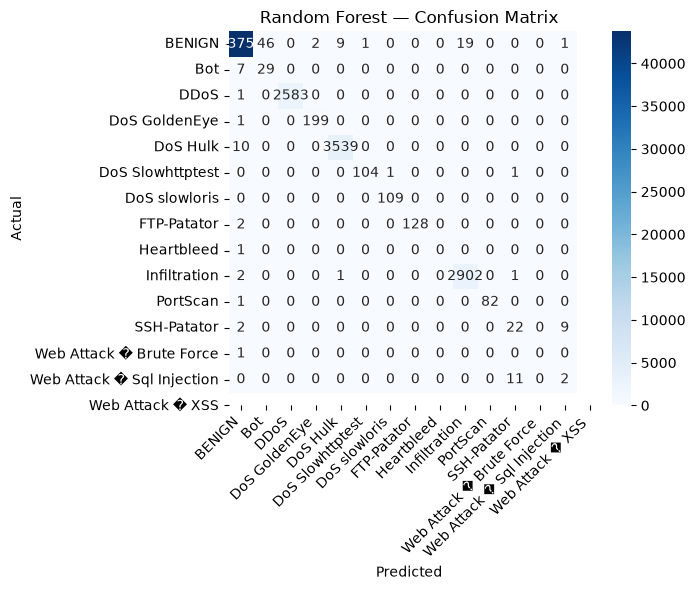

In [5]:
cm = np.array(row["Confusion Matrix"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "RandomForest_confusion_matrix.png"), dpi=150)
plt.show()


## Save Results & Model

In [6]:
save_results(MODEL_NAME, row)
joblib.dump(model, os.path.join(MODELS_DIR, "RandomForest.joblib"))
print("Saved model and results for", MODEL_NAME)


Saved results to results\Random_Forest_results.json
Saved model and results for Random Forest
